In [1]:
import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

2026-05-08 17:07:19.994709: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-08 17:07:20.012225: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-08 17:07:20.012245: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-08 17:07:20.012623: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-08 17:07:20.015836: I tensorflow/core/platform/cpu_feature_guar

TensorFlow: 2.15.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-05-08 17:07:20.770121: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-08 17:07:20.795340: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-08 17:07:20.801529: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [6]:
BASE_DIR = "/home/rubix-irat/esp_projects/csi_intrusion_pipeline"

DATASET_DIR = os.path.join(BASE_DIR, "data", "external", "tvat_raw")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")
MODEL_DIR = os.path.join(BASE_DIR, "data", "models")

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print("Dataset folder:", DATASET_DIR)
print("Processed folder:", PROCESSED_DIR)
print("Model folder:", MODEL_DIR)

Dataset folder: /home/rubix-irat/esp_projects/csi_intrusion_pipeline/data/external/tvat_raw
Processed folder: /home/rubix-irat/esp_projects/csi_intrusion_pipeline/data/processed
Model folder: /home/rubix-irat/esp_projects/csi_intrusion_pipeline/data/models


In [7]:
csv_files = sorted(glob.glob(os.path.join(DATASET_DIR, "*.csv")))

print("Total CSV files:", len(csv_files))

for f in csv_files[:10]:
    print(os.path.basename(f))

Total CSV files: 42
tvat-JJ-1.csv
tvat-JJ-2.csv
tvat-JJ-3.csv
tvat-JJ-4.csv
tvat-JJ-5.csv
tvat-JJ-6.csv
tvat-LA-1.csv
tvat-LA-2.csv
tvat-LA-3.csv
tvat-LA-4.csv


In [8]:
NORMAL_PREFIXES = ["NA"]

INTRUSION_PREFIXES = [
    "JJ",
    "LA",
    "LL",
    "RA",
    "RL",
    "SO"
]

def label_from_filename(path):
    name = os.path.basename(path)
    parts = name.replace(".csv", "").split("-")

    if len(parts) < 3:
        return None

    activity = parts[1]

    if activity in NORMAL_PREFIXES:
        return 0

    if activity in INTRUSION_PREFIXES:
        return 1

    return None

In [9]:
TARGET_SUBCARRIERS = 64

def parse_csi_line(line, target_subcarriers=TARGET_SUBCARRIERS):
    if "CSI_DATA" not in line:
        return None

    try:
        matches = re.findall(r"\[(.*?)\]", line)

        if not matches:
            return None

        values = list(map(int, matches[-1].split()))

        if len(values) < 2:
            return None

        if len(values) % 2 != 0:
            values = values[:-1]

        iq = np.array(values, dtype=np.float32)

        real = iq[::2]
        imag = iq[1::2]

        amplitude = np.sqrt(real**2 + imag**2)
        phase = np.arctan2(imag, real)

        n = min(len(amplitude), target_subcarriers)

        amp_fixed = np.zeros(target_subcarriers, dtype=np.float32)
        phase_fixed = np.zeros(target_subcarriers, dtype=np.float32)

        amp_fixed[:n] = amplitude[:n]
        phase_fixed[:n] = phase[:n]

        amp_fixed = (amp_fixed - np.mean(amp_fixed)) / (np.std(amp_fixed) + 1e-6)
        phase_fixed = (phase_fixed - np.mean(phase_fixed)) / (np.std(phase_fixed) + 1e-6)

        features = np.concatenate([amp_fixed, phase_fixed])

        return features, amp_fixed, phase_fixed

    except Exception:
        return None

In [10]:
def load_csi_file(path):
    features = []
    amps = []
    phases = []

    with open(path, "r", errors="ignore") as f:
        for line in f:
            parsed = parse_csi_line(line)

            if parsed is None:
                continue

            feat, amp, phase = parsed

            features.append(feat)
            amps.append(amp)
            phases.append(phase)

    if len(features) == 0:
        return None, None, None

    return (
        np.array(features, dtype=np.float32),
        np.array(amps, dtype=np.float32),
        np.array(phases, dtype=np.float32)
    )

Sample file: tvat-JJ-1.csv
Features: (6927, 128)
Amplitude: (6927, 64)
Phase: (6927, 64)


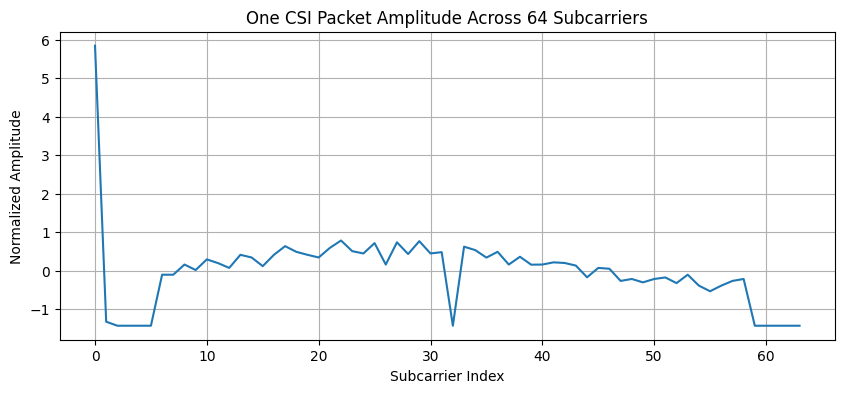

In [11]:
sample_file = csv_files[0]

feat, amp, phase = load_csi_file(sample_file)

print("Sample file:", os.path.basename(sample_file))
print("Features:", feat.shape)
print("Amplitude:", amp.shape)
print("Phase:", phase.shape)

plt.figure(figsize=(10, 4))
plt.plot(amp[0])
plt.title("One CSI Packet Amplitude Across 64 Subcarriers")
plt.xlabel("Subcarrier Index")
plt.ylabel("Normalized Amplitude")
plt.grid(True)
plt.show()

In [12]:
all_features = []
all_labels = []
all_amp_by_class = {
    0: [],
    1: []
}

for path in csv_files:
    label = label_from_filename(path)

    if label is None:
        print("Skipping unknown file:", os.path.basename(path))
        continue

    features, amps, phases = load_csi_file(path)

    if features is None:
        print("No valid CSI:", os.path.basename(path))
        continue

    all_features.append(features)
    all_labels.append(np.full(len(features), label))

    all_amp_by_class[label].append(amps)

    print(
        os.path.basename(path),
        "label=", label,
        "packets=", len(features)
    )

features_all = np.concatenate(all_features, axis=0)
labels_all = np.concatenate(all_labels, axis=0)

print("All packet features:", features_all.shape)
print("All labels:", labels_all.shape)
print("Class count:", np.bincount(labels_all))

tvat-JJ-1.csv label= 1 packets= 6927
tvat-JJ-2.csv label= 1 packets= 8239
tvat-JJ-3.csv label= 1 packets= 7886
tvat-JJ-4.csv label= 1 packets= 7662
tvat-JJ-5.csv label= 1 packets= 5474
tvat-JJ-6.csv label= 1 packets= 7172
tvat-LA-1.csv label= 1 packets= 4889
tvat-LA-2.csv label= 1 packets= 5553
tvat-LA-3.csv label= 1 packets= 4320
tvat-LA-4.csv label= 1 packets= 6736
tvat-LA-5.csv label= 1 packets= 7266
tvat-LA-6.csv label= 1 packets= 6459
tvat-LL-1.csv label= 1 packets= 7303
tvat-LL-2.csv label= 1 packets= 5499
tvat-LL-3.csv label= 1 packets= 6507
tvat-LL-4.csv label= 1 packets= 8220
tvat-LL-5.csv label= 1 packets= 6642
tvat-LL-6.csv label= 1 packets= 7165
tvat-NA-1.csv label= 0 packets= 5863
tvat-NA-2.csv label= 0 packets= 8219
tvat-NA-3.csv label= 0 packets= 6679
tvat-NA-4.csv label= 0 packets= 6793
tvat-NA-5.csv label= 0 packets= 6803
tvat-NA-6.csv label= 0 packets= 7866
tvat-RA-1.csv label= 1 packets= 7099
tvat-RA-2.csv label= 1 packets= 8213
tvat-RA-3.csv label= 1 packets= 6345
t

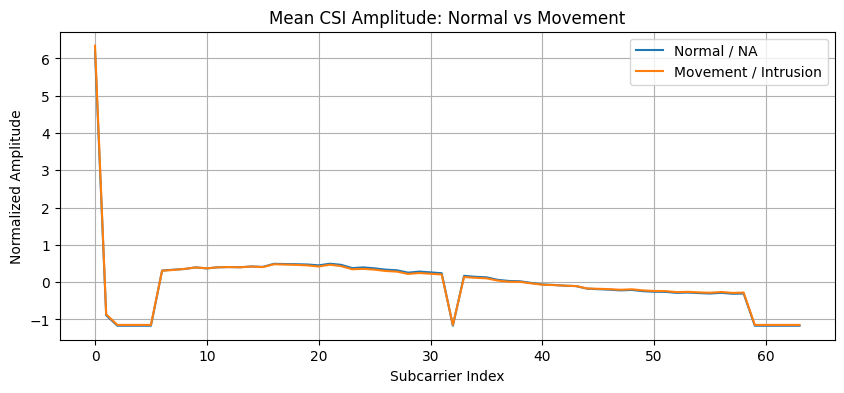

In [13]:
empty_amp_all = np.concatenate(all_amp_by_class[0], axis=0)
intrusion_amp_all = np.concatenate(all_amp_by_class[1], axis=0)

plt.figure(figsize=(10, 4))
plt.plot(np.mean(empty_amp_all, axis=0), label="Normal / NA")
plt.plot(np.mean(intrusion_amp_all, axis=0), label="Movement / Intrusion")
plt.title("Mean CSI Amplitude: Normal vs Movement")
plt.xlabel("Subcarrier Index")
plt.ylabel("Normalized Amplitude")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
all_features = []
all_labels = []
all_amp_by_class = {
    0: [],
    1: []
}

for path in csv_files:
    label = label_from_filename(path)

    if label is None:
        print("Skipping unknown file:", os.path.basename(path))
        continue

    features, amps, phases = load_csi_file(path)

    if features is None:
        print("No valid CSI:", os.path.basename(path))
        continue

    all_features.append(features)
    all_labels.append(np.full(len(features), label))

    all_amp_by_class[label].append(amps)

    print(
        os.path.basename(path),
        "label=", label,
        "packets=", len(features)
    )

features_all = np.concatenate(all_features, axis=0)
labels_all = np.concatenate(all_labels, axis=0)

print("All packet features:", features_all.shape)
print("All labels:", labels_all.shape)
print("Class count:", np.bincount(labels_all))

tvat-JJ-1.csv label= 1 packets= 6927
tvat-JJ-2.csv label= 1 packets= 8239
tvat-JJ-3.csv label= 1 packets= 7886
tvat-JJ-4.csv label= 1 packets= 7662
tvat-JJ-5.csv label= 1 packets= 5474
tvat-JJ-6.csv label= 1 packets= 7172
tvat-LA-1.csv label= 1 packets= 4889
tvat-LA-2.csv label= 1 packets= 5553
tvat-LA-3.csv label= 1 packets= 4320
tvat-LA-4.csv label= 1 packets= 6736
tvat-LA-5.csv label= 1 packets= 7266
tvat-LA-6.csv label= 1 packets= 6459
tvat-LL-1.csv label= 1 packets= 7303
tvat-LL-2.csv label= 1 packets= 5499
tvat-LL-3.csv label= 1 packets= 6507
tvat-LL-4.csv label= 1 packets= 8220
tvat-LL-5.csv label= 1 packets= 6642
tvat-LL-6.csv label= 1 packets= 7165
tvat-NA-1.csv label= 0 packets= 5863
tvat-NA-2.csv label= 0 packets= 8219
tvat-NA-3.csv label= 0 packets= 6679
tvat-NA-4.csv label= 0 packets= 6793
tvat-NA-5.csv label= 0 packets= 6803
tvat-NA-6.csv label= 0 packets= 7866
tvat-RA-1.csv label= 1 packets= 7099
tvat-RA-2.csv label= 1 packets= 8213
tvat-RA-3.csv label= 1 packets= 6345
t

In [15]:
WINDOW_SIZE = 50
STEP_SIZE = 10

def create_windows_from_file(path, label):
    features, amps, phases = load_csi_file(path)

    if features is None or len(features) < WINDOW_SIZE:
        return [], []

    X = []
    y = []

    for i in range(0, len(features) - WINDOW_SIZE + 1, STEP_SIZE):
        X.append(features[i:i + WINDOW_SIZE])
        y.append(label)

    return X, y

In [16]:
X_list = []
y_list = []

for path in csv_files:
    label = label_from_filename(path)

    if label is None:
        continue

    X_part, y_part = create_windows_from_file(path, label)

    if len(X_part) == 0:
        print("Skipping short file:", os.path.basename(path))
        continue

    X_list.extend(X_part)
    y_list.extend(y_part)

    print(
        os.path.basename(path),
        "label=", label,
        "windows=", len(X_part)
    )

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.int64)

idx = np.random.permutation(len(y))
X = X[idx]
y = y[idx]

print("X:", X.shape)
print("y:", y.shape)
print("Class count:", np.bincount(y))

tvat-JJ-1.csv label= 1 windows= 688
tvat-JJ-2.csv label= 1 windows= 819
tvat-JJ-3.csv label= 1 windows= 784
tvat-JJ-4.csv label= 1 windows= 762
tvat-JJ-5.csv label= 1 windows= 543
tvat-JJ-6.csv label= 1 windows= 713
tvat-LA-1.csv label= 1 windows= 484
tvat-LA-2.csv label= 1 windows= 551
tvat-LA-3.csv label= 1 windows= 428
tvat-LA-4.csv label= 1 windows= 669
tvat-LA-5.csv label= 1 windows= 722
tvat-LA-6.csv label= 1 windows= 641
tvat-LL-1.csv label= 1 windows= 726
tvat-LL-2.csv label= 1 windows= 545
tvat-LL-3.csv label= 1 windows= 646
tvat-LL-4.csv label= 1 windows= 818
tvat-LL-5.csv label= 1 windows= 660
tvat-LL-6.csv label= 1 windows= 712
tvat-NA-1.csv label= 0 windows= 582
tvat-NA-2.csv label= 0 windows= 817
tvat-NA-3.csv label= 0 windows= 663
tvat-NA-4.csv label= 0 windows= 675
tvat-NA-5.csv label= 0 windows= 676
tvat-NA-6.csv label= 0 windows= 782
tvat-RA-1.csv label= 1 windows= 705
tvat-RA-2.csv label= 1 windows= 817
tvat-RA-3.csv label= 1 windows= 630
tvat-RA-4.csv label= 1 windo

In [17]:
np.save(os.path.join(PROCESSED_DIR, "X_tvat_binary.npy"), X)
np.save(os.path.join(PROCESSED_DIR, "y_tvat_binary.npy"), y)

print("Saved:")
print(os.path.join(PROCESSED_DIR, "X_tvat_binary.npy"))
print(os.path.join(PROCESSED_DIR, "y_tvat_binary.npy"))

Saved:
/home/rubix-irat/esp_projects/csi_intrusion_pipeline/data/processed/X_tvat_binary.npy
/home/rubix-irat/esp_projects/csi_intrusion_pipeline/data/processed/y_tvat_binary.npy


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (22231, 50, 128)
Test: (5558, 50, 128)


In [19]:
model = Sequential([
    Conv1D(64, 3, activation="relu", input_shape=(X.shape[1], X.shape[2])),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(128, 3, activation="relu"),
    BatchNormalization(),
    MaxPooling1D(2),

    LSTM(64),

    Dropout(0.4),

    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

2026-05-08 17:16:37.264255: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-08 17:16:37.271847: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-08 17:16:37.273555: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 48, 64)            24640     
                                                                 
 batch_normalization (Batch  (None, 48, 64)            256       
 Normalization)                                                  
                                                                 
 max_pooling1d (MaxPooling1  (None, 24, 64)            0         
 D)                                                              
                                                                 
 conv1d_1 (Conv1D)           (None, 22, 128)           24704     
                                                                 
 batch_normalization_1 (Bat  (None, 22, 128)           512       
 chNormalization)                                                
                                                        

In [20]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32
)

Epoch 1/20


2026-05-08 17:16:55.277150: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-05-08 17:16:56.481064: I external/local_xla/xla/service/service.cc:168] XLA service 0x73ae9014a900 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-05-08 17:16:56.481080: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-05-08 17:16:56.485228: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778231816.541868  788930 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


556/556 [==============================] - 9s 11ms/step - loss: 0.3318 - accuracy: 0.8638 - val_loss: 0.4142 - val_accuracy: 0.8624
Epoch 2/20
556/556 [==============================] - 6s 11ms/step - loss: 0.2351 - accuracy: 0.9085 - val_loss: 0.2313 - val_accuracy: 0.9006
Epoch 3/20
556/556 [==============================] - 6s 11ms/step - loss: 0.1936 - accuracy: 0.9304 - val_loss: 0.2025 - val_accuracy: 0.9267
Epoch 4/20
556/556 [==============================] - 4s 7ms/step - loss: 0.1608 - accuracy: 0.9451 - val_loss: 0.1446 - val_accuracy: 0.9499
Epoch 5/20
556/556 [==============================] - 4s 8ms/step - loss: 0.1402 - accuracy: 0.9556 - val_loss: 0.2168 - val_accuracy: 0.9170
Epoch 6/20
556/556 [==============================] - 5s 10ms/step - loss: 0.1270 - accuracy: 0.9590 - val_loss: 0.2418 - val_accuracy: 0.9190
Epoch 7/20
556/556 [==============================] - 6s 10ms/step - loss: 0.1158 - accuracy: 0.9626 - val_loss: 0.1509 - val_accuracy: 0.9494
Epoch 8/20
5

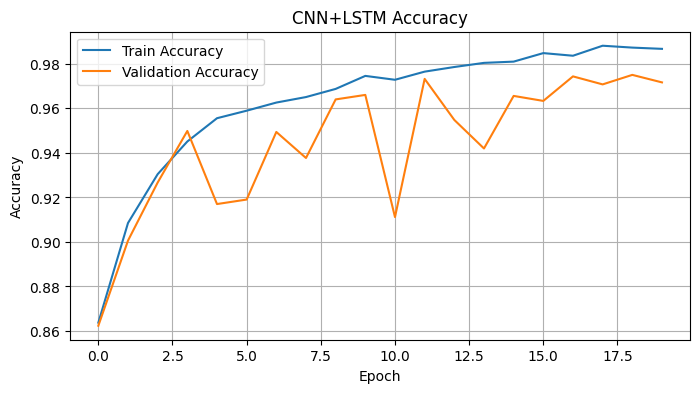

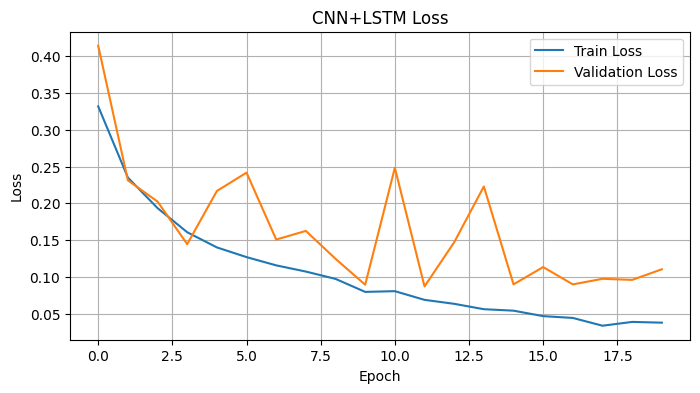

In [21]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("CNN+LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("CNN+LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
y_prob = model.predict(X_test)
y_pred = (y_prob > 0.5).astype(int).reshape(-1)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal / NA", "Movement / Intrusion"]
))

174/174 [==============================] - 1s 4ms/step
Confusion Matrix:
[[ 736  103]
 [  29 4690]]
Classification Report:
                      precision    recall  f1-score   support

         Normal / NA       0.96      0.88      0.92       839
Movement / Intrusion       0.98      0.99      0.99      4719

            accuracy                           0.98      5558
           macro avg       0.97      0.94      0.95      5558
        weighted avg       0.98      0.98      0.98      5558



In [23]:
MODEL_PATH = os.path.join(MODEL_DIR, "cnn_lstm_tvat_binary.h5")

model.save(MODEL_PATH)

print("Saved model:", MODEL_PATH)

Saved model: /home/rubix-irat/esp_projects/csi_intrusion_pipeline/data/models/cnn_lstm_tvat_binary.h5


/home/rubix-irat/esp_projects/csi_realtime_ml/csi_env/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [24]:
sample = X_test[0:1]

prob = model.predict(sample)[0][0]

print("Probability:", prob)

if prob > 0.5:
    print("Prediction: Movement / Intrusion")
else:
    print("Prediction: Normal / Empty")

1/1 [==============================] - 0s 110ms/step
Probability: 0.9998964
Prediction: Movement / Intrusion
